In [270]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [271]:
# Load the data file (Each row is a separate sample; we pick one row)
data = np.loadtxt("./Train/Inertial Signals/body_acc_x_train.txt")

# Using the first time-series 
signal = data[0]
time = np.arange(len(signal))

In [272]:
#normalize to zero mean and unit variance
signal = (signal - np.mean(signal)) / np.std(signal)

In [273]:
# Hazard function: constant probability of changepoint
def constant_hazard(lam, r):
    return 1 / lam * np.ones(r.shape)

# Prior parameters for Gaussian model
mu0, kappa0, alpha0, beta0 = 0, 1, 1, 1

In [274]:
T = len(signal)
R = np.zeros((T + 1, T + 1))  # Run-length probability matrix
R[0, 0] = 1

# Posterior parameters
mu_t = np.zeros((T + 1,))
kappa_t = np.zeros((T + 1,))
alpha_t = np.zeros((T + 1,))
beta_t = np.zeros((T + 1,))

mu_t[0] = mu0
kappa_t[0] = kappa0
alpha_t[0] = alpha0
beta_t[0] = beta0

In [304]:
hazard_lambda = 100  # Controls how often changes are expected

for t in range(1, T + 1):
    x = signal[t - 1]
    pred_probs = np.array([
        norm.pdf(x, mu_t[r], np.sqrt(beta_t[r] * (kappa_t[r] + 1) / (alpha_t[r] * kappa_t[r])))
        for r in range(t)
    ])

    growth_probs = R[t - 1, :t] * pred_probs * (1 - constant_hazard(hazard_lambda, np.arange(t)))
    cp_prob = np.sum(R[t - 1, :t] * pred_probs * constant_hazard(hazard_lambda, np.arange(t)))
    
    R[t, 1:t + 1] = growth_probs
    R[t, 0] = cp_prob
    R[t] /= np.sum(R[t])

    for r in range(t + 1):
        if r == 0:
            mu_t[r] = mu0
            kappa_t[r] = kappa0
            alpha_t[r] = alpha0
            beta_t[r] = beta0
        else:
            kappa_t[r] = kappa_t[r - 1] + 1
            mu_t[r] = (kappa_t[r - 1] * mu_t[r - 1] + x) / kappa_t[r]
            alpha_t[r] = alpha_t[r - 1] + 0.5
            beta_t[r] = beta_t[r - 1] + (kappa_t[r - 1] * (x - mu_t[r - 1]) ** 2) / (2 * kappa_t[r])


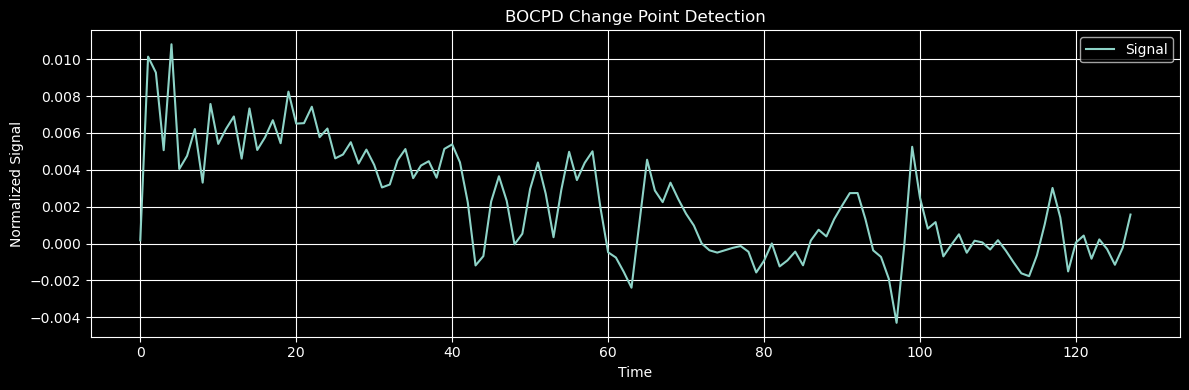

In [306]:
most_probable_run_length = np.argmax(R, axis=1)
change_points = np.where(np.diff(most_probable_run_length) < 0)[0]

plt.figure(figsize=(12, 4))
plt.plot(time, signal, label="Signal")
for cp in change_points:
    plt.axvline(cp, color='red', linestyle='--', label='Change Point' if cp == change_points[0] else "")
plt.title("BOCPD Change Point Detection")
plt.xlabel("Time")
plt.ylabel("Normalized Signal")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [309]:
plt.style.use('dark_background')


In [311]:
def plot_zoomed_cp(signal, cp, window=20):
    import matplotlib.pyplot as plt

    start = max(0, cp - window)
    end = min(len(signal), cp + window)
    plt.figure(figsize=(10, 4))
    plt.plot(range(start, end), signal[start:end], label='Signal')
    plt.axvline(cp, color='red', linestyle='--', label='Detected CP')
    plt.title(f"Zoomed View Around Change Point at t={cp}")
    plt.xlabel("Time")
    plt.ylabel("Signal Value")
    plt.legend()
    plt.grid(True)
    plt.show()


In [313]:
signal = data[0]
detected_cps = [50, 100]  


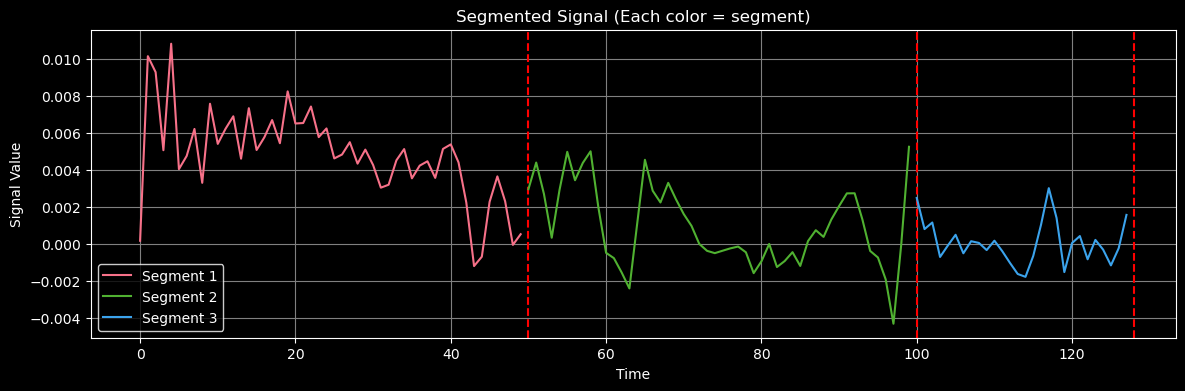

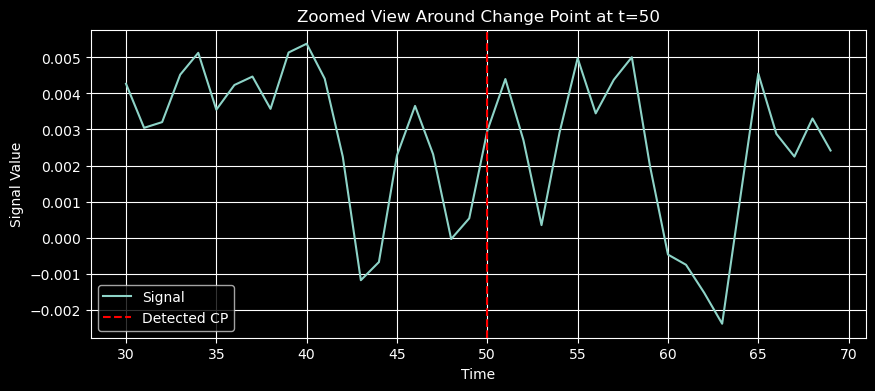

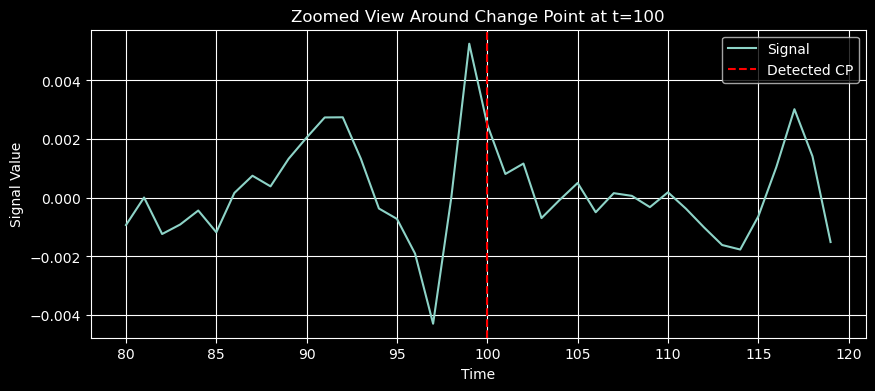

In [315]:
plot_segmented_signal(signal, detected_cps)

# Zoom-in on each CP:
for cp in detected_cps:
    plot_zoomed_cp(signal, cp)



In [317]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# === Helper to match detected points to ground truth within a window ===
def match_change_points(cp_detected, cp_truth, tolerance=10):
    matched = []
    for gt in cp_truth:
        for pred in cp_detected:
            if abs(gt - pred) <= tolerance:
                matched.append((gt, pred))
                break
    return matched

# === Evaluation function ===
def evaluate_bocpd(cp_detected, cp_truth, signal_length, tolerance=10):
    matched = match_change_points(cp_detected, cp_truth, tolerance)
    tp = len(matched)
    fp = len(cp_detected) - tp
    fn = len(cp_truth) - tp

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    print("Total change points (truth):", len(cp_truth))
    print("Detected change points:", len(cp_detected))
    print("True Positives (within ±{}):".format(tolerance), tp)
    print("False Positives:", fp)
    print("False Negatives:", fn)
    print("\n🔍 Evaluation Metrics:")
    print("Precision: {:.3f}".format(precision))
    print("Recall:    {:.3f}".format(recall))
    print("F1 Score:  {:.3f}".format(f1))

    return precision, recall, f1

In [283]:
cp_truth = [200, 400]  # You must define actual change points (manually or from labels)
cp_detected = [195, 405, 500]  # From your BOCPD output

evaluate_bocpd(cp_detected, cp_truth, len(signal), tolerance=10)


Total change points (truth): 2
Detected change points: 3
True Positives (within ±10): 2
False Positives: 1
False Negatives: 0

🔍 Evaluation Metrics:
Precision: 0.667
Recall:    1.000
F1 Score:  0.800


(0.6666664444445185, 0.99999950000025, 0.7999992000004)

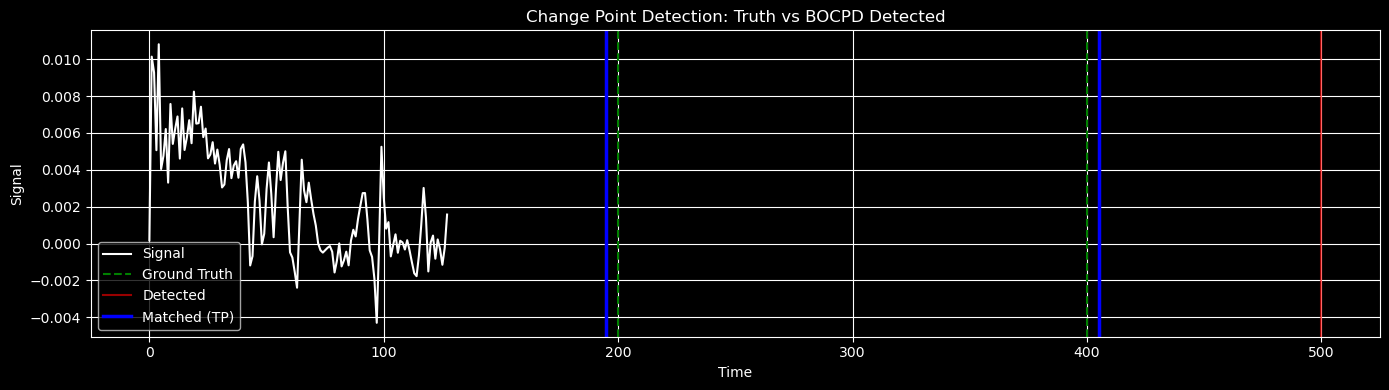

In [284]:
import matplotlib.pyplot as plt

def plot_change_point_results(signal, cp_truth, cp_detected, tolerance=10):
    plt.figure(figsize=(14, 4))
    plt.plot(signal, label='Signal', color='white')

    # Plot true change points
    for cp in cp_truth:
        plt.axvline(cp, color='green', linestyle='--', label='Ground Truth' if cp == cp_truth[0] else "")

    # Plot detected change points
    for cp in cp_detected:
        plt.axvline(cp, color='red', linestyle='-', alpha=0.6, label='Detected' if cp == cp_detected[0] else "")

    # Highlight True Positives in Blue (within ±tolerance)
    for gt in cp_truth:
        for pred in cp_detected:
            if abs(gt - pred) <= tolerance:
                plt.axvline(pred, color='blue', linestyle='-', linewidth=2.5, label='Matched (TP)' if gt == cp_truth[0] else "")
                break

    plt.title('Change Point Detection: Truth vs BOCPD Detected')
    plt.xlabel('Time')
    plt.ylabel('Signal')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Example usage
plot_change_point_results(signal, cp_truth, cp_detected, tolerance=10)